# Data (from week 1) needed for our week 2 response
## Import

In [109]:

import xarray as xr
import pandas as pd
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import seaborn as sns
import scipy
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import statsmodels.api as sm


## Init

In [2]:
main_data_folder = "data/"
gadm_filepath = main_data_folder + "gadm_410_europe.gpkg"
country_code = "ESP" # Spain
cityname = "Madrid"

In [3]:
gadm_gdf = gpd.read_file(gadm_filepath)

print(f"Number of rows in GADM: {len(gadm_gdf)}")
filtered_gadm_gdf = gadm_gdf[(gadm_gdf.GID_0 == country_code) & (gadm_gdf.NAME_2 == cityname)]

print(f"Number of rows in GADM after filtering: {len(filtered_gadm_gdf)}")
filtered_gadm_gdf.head()

Number of rows in GADM: 106252
Number of rows in GADM after filtering: 181


,UID,GID_0,NAME_0,GID_1,NAME_1,ENGTYPE_1,GID_2,NAME_2,ENGTYPE_2,GID_3,...,ENGTYPE_3,GID_4,NAME_4,ENGTYPE_4,GID_5,NAME_5,ENGTYPE_5,COUNTRY,CONTINENT,geometry
90995,305016,ESP,Spain,ESP.8_1,Comunidad de Madrid,Autonomous Community,ESP.8.1_1,Madrid,Province,ESP.8.1.1_1,...,Comarca,ESP.8.1.1.1_1,Alameda del Valle,Municipality,,,,Spain,Europe,"MULTIPOLYGON (((-3.89887 40.95908, -3.89501 40..."
90996,305017,ESP,Spain,ESP.8_1,Comunidad de Madrid,Autonomous Community,ESP.8.1_1,Madrid,Province,ESP.8.1.1_1,...,Comarca,ESP.8.1.1.2_1,Berzosa del Lozoya,Municipality,,,,Spain,Europe,"MULTIPOLYGON (((-3.4963 40.99471, -3.49791 40...."
90997,305018,ESP,Spain,ESP.8_1,Comunidad de Madrid,Autonomous Community,ESP.8.1_1,Madrid,Province,ESP.8.1.1_1,...,Comarca,ESP.8.1.1.3_1,Braojos,Municipality,,,,Spain,Europe,"MULTIPOLYGON (((-3.70555 41.07751, -3.69502 41..."
90998,305019,ESP,Spain,ESP.8_1,Comunidad de Madrid,Autonomous Community,ESP.8.1_1,Madrid,Province,ESP.8.1.1_1,...,Comarca,ESP.8.1.1.4_1,Buitrago del Lozoya,Municipality,,,,Spain,Europe,"MULTIPOLYGON (((-3.6451 40.95414, -3.65023 40...."
90999,305020,ESP,Spain,ESP.8_1,Comunidad de Madrid,Autonomous Community,ESP.8.1_1,Madrid,Province,ESP.8.1.1_1,...,Comarca,ESP.8.1.1.5_1,Bustarviejo,Municipality,,,,Spain,Europe,"MULTIPOLYGON (((-3.79052 40.84676, -3.786 40.8..."


In [4]:
one_city_gdf = filtered_gadm_gdf.dissolve()

one_city_gdf.head()

,geometry,UID,GID_0,NAME_0,GID_1,NAME_1,ENGTYPE_1,GID_2,NAME_2,ENGTYPE_2,...,NAME_3,ENGTYPE_3,GID_4,NAME_4,ENGTYPE_4,GID_5,NAME_5,ENGTYPE_5,COUNTRY,CONTINENT
0,"MULTIPOLYGON (((-4.55042 40.20185, -4.57506 40...",305016,ESP,Spain,ESP.8_1,Comunidad de Madrid,Autonomous Community,ESP.8.1_1,Madrid,Province,...,n.a. (175),Comarca,ESP.8.1.1.1_1,Alameda del Valle,Municipality,,,,Spain,Europe


## ERA-5 Land


In [5]:
era5_data_folder = main_data_folder + "derived-era5-land-daily-statistics/"

variable2statistic = {
    "2m_temperature": "daily_maximum",
    "total_precipitation": "daily_mean",
    "10m_u_component_of_wind": "daily_mean",
    "10m_v_component_of_wind": "daily_mean",
}

variable2datavar = {
    "2m_temperature": "t2m",
    "total_precipitation": "tp",
    "10m_u_component_of_wind": "u10",
    "10m_v_component_of_wind": "v10",
}
origin_crs = "EPSG:4326"

variable = "2m_temperature"
year = 2020
statistic = variable2statistic[variable]
datavar = variable2datavar[variable]
filepath = f"{era5_data_folder}{year}_{variable}_{statistic}.nc"
ds = xr.open_dataset(filepath)
print(ds)
lat, lon = 39.8960, -2.4876
filepaths = glob(f"{era5_data_folder}*_{variable}_{statistic}.nc")
ds = xr.open_mfdataset(filepaths, combine="by_coords")


<xarray.Dataset> Size: 338MB
Dimensions:     (valid_time: 366, latitude: 350, longitude: 660)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
  * latitude    (latitude) float64 3kB 69.9 69.8 69.7 69.6 ... 35.2 35.1 35.0
  * longitude   (longitude) float64 5kB -25.0 -24.9 -24.8 ... 40.7 40.8 40.9
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 338MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-03T16:43 GRIB to CDM+CF via cfgrib-0.9.1...


## NDVI

In [6]:
ndvi_data_folder = main_data_folder + "sentinel2_ndvi/"

def quarter2timeperiod(year, quarter):
    if quarter == 1:
        return f"{year-1}-12-01_{year}-03-01"
    elif quarter == 2:
        return f"{year}-03-01_{year}-06-01"
    elif quarter == 3:
        return f"{year}-06-01_{year}-09-01"
    elif quarter == 4:
        return f"{year}-09-01_{year}-12-01"
    else:
        raise ValueError("quarter must be in 1, 2, 3, 4")


In [7]:
available_years = [2020, 2021, 2022, 2023]
available_quarters = [1, 2, 3, 4]
year = 2020
quarter = 3
timeperiod = quarter2timeperiod(year, quarter)

filepath  = f"{ndvi_data_folder}ndvi_{timeperiod}.tif"
day = pd.to_datetime(f"{year}-06-01")


In [8]:
def convert_ndvi_to_real_scale(ndvi_img, out_meta):
    # The NDVI is stored in int8 format on a 0/254 scale, and nodata is 255.
    # This function converts it to a float format on a -1/1 scale, and replace nodata with np.nan.
    ndvi_img = ndvi_img.astype(float)
    ndvi_img[ndvi_img == out_meta["nodata"]] = np.nan
    ndvi_img = ndvi_img / 254 * 2 - 1
    return ndvi_img

def get_out_image_and_metadata(filepath, one_city_gdf):
    with rasterio.open(filepath) as src:
        one_city_gdf_in_good_crs = one_city_gdf.to_crs(src.crs)
        city_geometry = [one_city_gdf_in_good_crs.geometry.iloc[0]]
        out_image, out_transform = mask(src, city_geometry, crop=True)
        out_meta = src.meta

        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        real_out_image = convert_ndvi_to_real_scale(out_image, out_meta)

    return real_out_image, out_meta

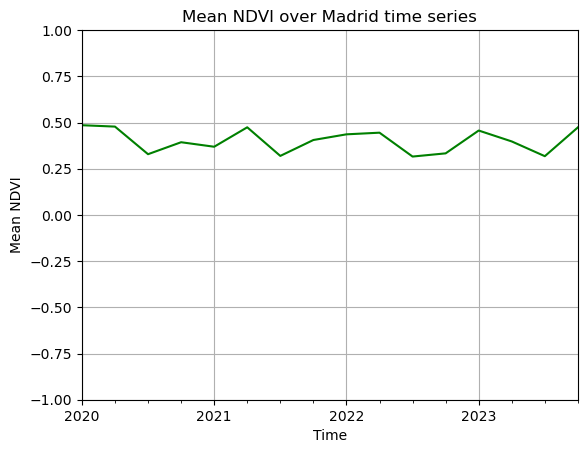

In [9]:
mean_ndvi_time_series = pd.Series(dtype=float)
for year in available_years:
    for quarter in available_quarters:
        timeperiod = quarter2timeperiod(year, quarter)
        filepath  = f"{ndvi_data_folder}ndvi_{timeperiod}.tif"
        date = pd.to_datetime(timeperiod.split("_")[1])
        current_real_out_image, _ = get_out_image_and_metadata(filepath, one_city_gdf)
        current_mean_ndvi = np.nanmean(current_real_out_image[0])
        mean_ndvi_time_series.loc[date] = current_mean_ndvi

mean_ndvi_time_series = mean_ndvi_time_series.sort_index()

plt.figure()
mean_ndvi_time_series.plot(color='green')
plt.title(f"Mean NDVI over {cityname} time series")
plt.ylabel("Mean NDVI")
plt.xlabel("Time")
plt.ylim(-1, 1)
plt.grid()
plt.show()

## Reprojection

In [10]:
da = ds[datavar].sel(valid_time=day)
real_out_image, out_meta = get_out_image_and_metadata(filepath, one_city_gdf)

origin_transform = from_bounds(
    ds.longitude.min().item(),
    ds.latitude.min().item(),
    ds.longitude.max().item(),
    ds.latitude.max().item(),
    len(ds.longitude),
    len(ds.latitude)
)
origin_crs = "EPSG:4326"

target_transform = out_meta["transform"]
target_crs = out_meta["crs"]

reprojected_da = da.rio.write_crs(origin_crs).rio.reproject(
    dst_crs=target_crs,
    shape=(out_meta["height"], out_meta["width"]),
    transform=target_transform,
)

## Stations



In [11]:
eca_tx_datafolder = main_data_folder + "ECA_blend_tx/"
stations_filepath = eca_tx_datafolder + "stations.txt"
def dms_to_decimal(dms_str):
    # This function converts a DMS (Degrees:Minutes:Seconds) string to decimal degrees.
    dms_str = dms_str.strip()
    
    sign = 1 if dms_str[0] == '+' else -1
    
    dms_str = dms_str[1:]
    
    parts = dms_str.split(':')
    degrees = float(parts[0])
    minutes = float(parts[1])
    seconds = float(parts[2])
    
    decimal = sign * (degrees + minutes/60 + seconds/3600)
    
    return decimal

In [12]:
stations_df = pd.read_csv(
    stations_filepath,
    skiprows=17,
    skipinitialspace=True
)

stations_df['LAT_decimal'] = stations_df['LAT'].apply(dms_to_decimal)
stations_df['LON_decimal'] = stations_df['LON'].apply(dms_to_decimal)

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df['LON_decimal'], stations_df['LAT_decimal']),
    crs="EPSG:4326" # (WGS84, adequate for lat/lon coordinates)
).drop(columns=['LAT', 'LON', 'LAT_decimal', 'LON_decimal'])

one_city_gdf.to_crs(stations_gdf.crs, inplace=True) # Use same CRS for spatial operations

stations_in_city_gdf = stations_gdf[stations_gdf.within(one_city_gdf.geometry.iloc[0])]
selected_station = stations_in_city_gdf.iloc[9]
selected_station_gdf = gpd.GeoDataFrame([selected_station], crs=stations_in_city_gdf.crs)
selected_station_STAID = selected_station['STAID']

station_data_filepath = eca_tx_datafolder + f"TX_STAID{selected_station_STAID:06d}.txt"

station_data_df = pd.read_csv(
    station_data_filepath,
    skiprows=20,
    skipinitialspace=True
)

valid_data_df = station_data_df[station_data_df['Q_TX'] == 0].copy() # Q_TX is the quality code for TX (0='valid')
valid_data_df['DATE'] = pd.to_datetime(valid_data_df['DATE'], format='%Y%m%d')
valid_data_df['TX_celsius'] = valid_data_df['TX'] / 10 # Convert temperature to °C (originally stored in 0.1°C unit)

tx_timeseries = pd.Series(
    valid_data_df['TX_celsius'].values,
    index=valid_data_df['DATE']
)

print(f"Number of valid daily records for station {selected_station_STAID}: {len(tx_timeseries)}")


Number of valid daily records for station 27223: 5992


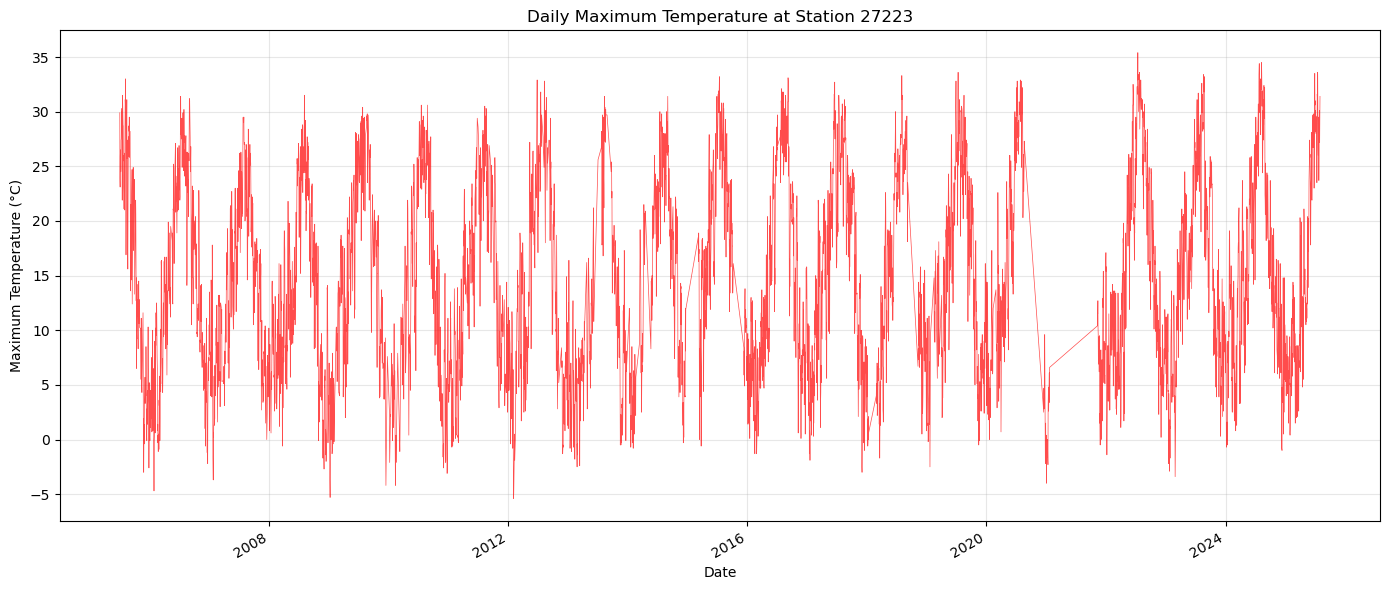

In [13]:
plt.figure(figsize=(14, 6))
tx_timeseries.plot(color='red', linewidth=0.5, alpha=0.7)
plt.title(f"Daily Maximum Temperature at Station {selected_station_STAID}")
plt.ylabel("Maximum Temperature (°C)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Our answers for week 2

In [14]:
point=stations_in_city_gdf.loc[stations_in_city_gdf['STAID'] == 27223, 'geometry'].iloc[0]
longitude = point.x
latitude = point.y


In [15]:
ds_sel = ds[datavar].sel(latitude=latitude, longitude=longitude, method="nearest")
ds_sel_to_celsius = ds_sel - 273.15
era5_timed_series=ds_sel_to_celsius.to_series()


In [16]:
plt.figure(figsize=(14, 6))
start_date = '2020-01-01'
end_date = '2026-12-31'
tx_timeseries_filtered = tx_timeseries.loc[start_date:end_date]

<Figure size 1400x600 with 0 Axes>

## Useful functions

In [17]:
def quarter(month):
    if 1<=month<=3:
        return 1
    elif 4<=month<=6:
        return 2
    elif 7<=month<=9:
        return 3
    return 4

In [18]:
"""Sorting the discrepancies by quarter"""
def transform_daily_into_quarter(discrepancies_daily):

    mean_discrepancies_by_quarter = pd.Series(dtype=float)
    valuesbyquarter = {}
    for date in discrepancies_daily.keys():
        year=date.year;month=date.month
        periodOfTime = quarter2timeperiod(year, quarter(month))
        new_date=pd.to_datetime(periodOfTime.split("_")[1])
        if new_date in mean_discrepancies_by_quarter.keys() and not np.isnan(discrepancies_daily[date]):
            valuesbyquarter[new_date].append(discrepancies_daily[date])
            mean_discrepancies_by_quarter[new_date]=np.mean(valuesbyquarter[new_date])
        elif new_date not in mean_discrepancies_by_quarter.keys() and not np.isnan(discrepancies_daily[date]):
            valuesbyquarter[new_date]=[discrepancies_daily[date]]
            mean_discrepancies_by_quarter[new_date]=discrepancies_daily[date]

    mean_discrepancies_by_quarter.sort_index()
    return mean_discrepancies_by_quarter

"""Restricting only to summer"""
def transform_daily_into_summer_only(discrepancies_daily):

    mean_discrepancies_by_quarter = pd.Series(dtype=float)
    valuesbyquarter = {}
    for date in discrepancies_daily.keys():
        year=date.year;month=date.month
        periodOfTime = quarter2timeperiod(year, quarter(month))
        new_date=pd.to_datetime(periodOfTime.split("_")[1])
        if quarter(month)==3:
            if new_date in mean_discrepancies_by_quarter.keys() and not np.isnan(discrepancies_daily[date]):
                valuesbyquarter[new_date].append(discrepancies_daily[date])
                mean_discrepancies_by_quarter[new_date]=np.mean(valuesbyquarter[new_date])
            elif new_date not in mean_discrepancies_by_quarter.keys() and not np.isnan(discrepancies_daily[date]):
                valuesbyquarter[new_date]=[discrepancies_daily[date]]
                mean_discrepancies_by_quarter[new_date]=discrepancies_daily[date]

    mean_discrepancies_by_quarter.sort_index()
    return mean_discrepancies_by_quarter

# 1. What we did in Week 2 : Comparison with all stations

In [19]:
staids = stations_in_city_gdf["STAID"].unique()
num_stations = len(staids)
full_selected_stations={}
timed_series_stations={}
era5_timed_series_by_stations=pd.DataFrame({})

In [20]:
for staid in staids:
    point_i=stations_in_city_gdf.loc[stations_in_city_gdf['STAID'] == staid, 'geometry'].iloc[0]
    longitude_i = point_i.x
    latitude_i = point_i.y
    ds_sel_i = ds[datavar].sel(latitude=latitude_i, longitude=longitude_i, method="nearest")
    ds_sel_to_celsius_i = ds_sel_i - 273.15
    era5_timed_series_i=ds_sel_to_celsius_i.to_series()

    era5_timed_series_by_stations[staid]=era5_timed_series_i
station_cols = era5_timed_series_by_stations.columns
era5_timed_series_by_stations['Mean_stations'] = era5_timed_series_by_stations[station_cols].mean(axis=1)

era5_timed_series_by_stations.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
valid_time,,,,,,,,,,,,,,,,,,,,,
2020-01-01,11.437592,11.612579,12.081329,11.648529,11.546967,11.162201,10.795013,10.929657,12.053986,11.582001,...,11.575470,11.117279,11.720795,11.546967,11.279388,12.231720,12.089935,12.307892,12.341095,11.649053
2020-01-02,9.301971,9.438141,9.705719,9.432281,9.346893,9.272675,9.163300,9.245514,10.140045,10.317780,...,9.426422,9.243378,9.451813,9.346893,9.462128,9.695953,9.891266,9.912750,9.713531,9.544270
2020-01-03,9.165497,8.638153,8.745575,9.136200,9.540497,8.974091,8.497528,7.035248,7.839935,7.162201,...,8.440887,8.401825,9.472137,9.540497,8.220184,8.716888,10.450653,10.343231,9.712372,8.883898
2020-01-04,10.441650,9.658447,8.115479,10.136963,10.467041,10.562744,10.263916,5.467041,6.215088,5.355713,...,9.402588,10.215088,10.265869,10.467041,9.734619,6.980713,9.750885,9.887604,8.863525,9.143907
2020-01-05,11.763184,11.747559,11.520996,11.940918,11.886230,11.429199,10.626465,9.441040,11.222290,10.302368,...,11.673340,11.228027,12.056152,11.886230,11.028809,10.917480,11.386230,11.720215,11.554199,11.395921


In [21]:
for i in range(num_stations):
    selected_station_i = stations_in_city_gdf.iloc[i]
    full_selected_stations[staids[i]] = gpd.GeoDataFrame([selected_station_i], crs=stations_in_city_gdf.crs)
    selected_station_STAID_i = selected_station_i['STAID']
    station_data_filepath_i = eca_tx_datafolder + f"TX_STAID{selected_station_STAID_i:06d}.txt"

    station_data_df_i = pd.read_csv(
        station_data_filepath_i,
        skiprows=20,
        skipinitialspace=True
    )

    valid_data_df_i = station_data_df_i[station_data_df_i['Q_TX'] == 0].copy() # Q_TX is the quality code for TX (0='valid')
    valid_data_df_i['DATE'] = pd.to_datetime(valid_data_df_i['DATE'], format='%Y%m%d')
    valid_data_df_i['TX_celsius'] = valid_data_df_i['TX'] / 10 # Convert temperature to °C (originally stored in 0.1°C unit)

    tx_timeseries_i = pd.Series(
        valid_data_df_i['TX_celsius'].values,
        index=valid_data_df_i['DATE']
    )
    timed_series_stations[staids[i]]=tx_timeseries_i



In [22]:
stations_df = pd.DataFrame({})
for staid in staids:
    stations_df[staid]=timed_series_stations[staid]
station_cols = stations_df.columns
stations_df['Mean_stations'] = stations_df[station_cols].mean(axis=1)

In [23]:
stations_df=stations_df.dropna()
stations_df.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
DATE,,,,,,,,,,,,,,,,,,,,,
2012-02-19,13.4,14.6,11.7,15.0,14.4,14.8,15.0,10.7,10.0,5.5,...,15.1,15.7,15.0,15.0,14.3,15.3,12.0,13.7,13.6,13.400000
2012-02-22,14.6,16.2,13.0,16.3,15.5,16.2,16.1,14.1,13.7,9.0,...,16.5,17.3,16.8,16.6,15.6,15.6,13.5,15.2,14.3,14.995238
2012-02-26,20.4,21.3,18.8,22.0,21.0,21.5,22.4,17.8,16.7,11.7,...,22.3,22.7,22.0,22.2,21.5,18.9,18.2,19.8,20.6,20.138095
2012-02-27,18.8,19.0,16.9,20.2,20.0,20.2,20.9,17.8,17.5,14.7,...,20.5,20.4,19.8,20.6,20.1,20.9,17.5,19.1,19.5,19.066667
2012-02-28,18.6,19.7,17.0,20.9,19.5,20.2,21.5,17.3,16.2,15.5,...,20.8,21.7,20.2,20.4,20.9,19.7,17.5,19.5,19.0,19.204762


In [24]:
discreptancies_by_stations = pd.DataFrame({})
for staid in staids:
    discreptancies_by_stations[staid]=(stations_df[staid]-era5_timed_series_by_stations[staid]).dropna()
discreptancies_by_stations['Mean_stations']=stations_df['Mean_stations']-era5_timed_series_by_stations['Mean_stations']
discreptancies_by_stations.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
2020-01-01,-0.237592,1.687421,0.218671,1.151471,1.953033,1.637799,1.704987,7.070343,3.246014,1.417999,...,2.024530,2.182721,1.979205,3.853033,1.320612,5.268280,1.910065,1.192108,1.558905,2.065233
2020-01-02,1.198029,2.761859,0.694281,3.467719,2.653107,3.127325,4.236700,6.454486,2.359955,4.082220,...,3.473578,3.056622,2.648187,3.753107,2.437872,4.704047,2.708734,1.887250,2.286469,2.993826
2020-01-03,-3.165497,-4.038153,-1.445575,-4.636200,-2.840497,-3.174091,-1.697528,4.764752,2.660065,-4.062201,...,-2.540887,-2.901825,-2.872137,-1.840497,-2.220184,0.783112,-3.050653,-2.643231,-2.212372,-2.145803
2020-01-04,0.758350,2.241553,1.584521,2.263037,1.432959,1.437256,2.836084,7.632959,5.084912,-1.255713,...,3.197412,2.684912,1.534131,2.132959,2.665381,3.919287,0.649115,0.712396,2.036475,2.217998
2020-01-05,-0.863184,-0.047559,1.479004,1.059082,1.613770,0.970801,1.073535,8.158960,5.977710,4.097632,...,1.026660,0.571973,1.243848,3.613770,0.771191,7.382520,1.313770,2.279785,2.745801,2.251698


## Calculate NDVI for each station area + the city

In [25]:
ndvi_stations_dict = {staid: [] for staid in stations_in_city_gdf['STAID']}
ndvi_dates = []

for year in available_years:
    for q in available_quarters:
        timeperiod = quarter2timeperiod(year, q)
        filepath = f"{ndvi_data_folder}ndvi_{timeperiod}.tif"
        
        current_date = pd.to_datetime(timeperiod.split("_")[1])
        ndvi_dates.append(current_date)
        
        with rasterio.open(filepath) as src:
            stations_projected = stations_in_city_gdf.to_crs(src.crs)
            
            coords = [(geom.x, geom.y) for geom in stations_projected.geometry]
            
            sampled_values = src.sample(coords)
            
            for staid, val in zip(stations_in_city_gdf['STAID'], sampled_values):
                raw_val = val[0] 
                
                if raw_val == src.nodata:
                    real_ndvi = np.nan
                else:
                    real_ndvi = (float(raw_val) / 254.0 * 2.0) - 1.0
                
                ndvi_stations_dict[staid].append(real_ndvi)
ndvi_stations_dict['Mean_stations']=mean_ndvi_time_series
ndvi_stations_df = pd.DataFrame(ndvi_stations_dict, index=ndvi_dates)
ndvi_stations_df = ndvi_stations_df.sort_index()

ndvi_stations_df.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
2020-03-01,0.590551,0.818898,0.125984,0.700787,0.181102,0.401575,0.448819,0.566929,0.535433,0.551181,...,0.496063,0.251969,0.645669,0.212598,0.251969,0.023622,0.629921,0.338583,0.409449,0.485405
2020-06-01,0.503937,0.716535,0.118110,0.535433,0.149606,0.283465,0.440945,0.614173,0.622047,0.629921,...,0.346457,0.267717,0.551181,0.204724,0.212598,0.031496,0.661417,0.299213,0.519685,0.477942
2020-09-01,0.582677,0.220472,0.070866,0.181102,0.078740,0.118110,0.370079,0.370079,0.370079,0.566929,...,0.228346,0.228346,0.314961,0.228346,0.173228,0.023622,0.551181,0.133858,0.251969,0.328603
2020-12-01,0.590551,0.472441,0.102362,0.543307,0.110236,0.157480,0.409449,0.598425,0.456693,0.590551,...,0.283465,0.314961,0.511811,0.228346,0.212598,0.023622,0.606299,0.251969,0.433071,0.393353
2021-03-01,0.480315,0.637795,0.118110,0.653543,0.149606,0.196850,0.338583,0.299213,0.448819,0.346457,...,0.283465,0.133858,0.535433,0.173228,0.204724,0.039370,0.377953,0.212598,0.433071,0.368942


## Without any restriction on the period

In [26]:
station_discreptancies_by_quarter = pd.DataFrame({})
for staid in staids:
    station_discreptancies_by_quarter[staid]=transform_daily_into_quarter(discreptancies_by_stations[staid])
station_discreptancies_by_quarter['Mean_stations']=transform_daily_into_quarter(discreptancies_by_stations['Mean_stations'])

station_discreptancies_by_quarter.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
2020-03-01,-0.031956,1.055461,-0.378157,1.333767,0.752138,0.507897,1.611813,4.617910,2.189812,-0.272971,...,1.799363,1.331406,0.717705,1.107694,1.250319,3.534250,-1.032164,-0.168427,0.346457,1.023505
2020-06-01,0.725781,1.945519,-0.223270,2.349689,1.318142,0.970254,1.880451,4.744532,1.883920,-0.315440,...,2.440427,1.999559,1.562050,1.353142,1.988264,3.780429,-0.715566,-0.249782,0.185868,1.415838
2020-09-01,-0.059874,1.516615,-0.255422,2.062318,1.443334,0.962157,0.896992,4.473071,1.700148,-0.043726,...,2.118016,1.656187,0.448646,1.383334,1.324492,2.884634,0.224037,-0.170885,0.528763,1.166511
2020-12-01,-0.827890,-1.137561,-1.639252,-0.934045,-0.985507,-1.259726,-1.519882,2.533405,0.531500,-3.261664,...,-0.175061,-1.153085,-0.274866,-0.485507,-1.042734,1.182233,-1.617892,-0.974554,-1.075336,-0.773998
2021-12-01,0.674965,2.252197,1.337363,2.108027,1.984828,1.760194,2.510160,5.165492,3.405802,-0.175787,...,2.902165,2.796718,0.832263,2.610754,2.104545,4.620306,0.186094,1.261780,1.844120,2.095596


In [27]:
correlations= {}
bias = {}
mse = {}
std = {}
ci = {}
# 1.96* (std/np.sqrt(len(df)))

for staid in staids:
    bias[staid]= discreptancies_by_stations[staid].mean()
    mse[staid]= np.mean(discreptancies_by_stations[staid]**2)
    std[staid] = discreptancies_by_stations[staid].std() 
    ci[staid]=1.96 * (std[staid]/np.sqrt(len(discreptancies_by_stations[staid])))
    correlations[staid]= station_discreptancies_by_quarter[staid].corr(ndvi_stations_df[staid])
bias['Mean_stations']= discreptancies_by_stations[staid].mean()
mse['Mean_stations']= np.mean(discreptancies_by_stations[staid]**2)
std['Mean_stations'] = discreptancies_by_stations[staid].std() 
correlations['Mean_stations']= station_discreptancies_by_quarter[staid].corr(ndvi_stations_df['Mean_stations'])
ci['Mean_stations']=1.96 * (std['Mean_stations']/np.sqrt(len(discreptancies_by_stations['Mean_stations'])))

correlations['Mean_stations']= station_discreptancies_by_quarter['Mean_stations'].corr(mean_ndvi_time_series)
correlation_with_ndvi = pd.DataFrame([bias, correlations, mse, std, ci])
correlation_with_ndvi.index = ['Bias', 'Correlation with NDVI', 'MSE', 'STD', 'CI']
correlation_with_ndvi.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
Bias,0.294517,1.904889,0.195731,1.893727,1.112443,0.976651,1.770086,4.772084,2.347434,-0.254246,...,2.472451,2.119043,0.854261,1.497422,1.864654,3.943321,-0.483170,-0.074671,0.587284,0.587284
Correlation with NDVI,-0.569489,0.003507,0.128108,-0.276982,-0.036028,-0.072768,-0.220213,-0.054258,0.169111,-0.062770,...,-0.047995,-0.159013,-0.171129,0.113891,-0.210422,0.452131,-0.365261,0.131104,0.078879,0.050868
MSE,1.361402,5.161676,1.565265,5.153385,2.479725,2.165783,4.615536,25.341271,7.277936,2.221791,...,7.608929,6.286709,2.349425,4.122745,4.727524,18.123083,2.117411,1.280564,1.878677,1.878677
STD,1.129774,1.239012,1.236537,1.252719,1.115294,1.101626,1.218334,1.603735,1.330371,1.469719,...,1.223905,1.341193,1.273521,1.372232,1.119055,1.605237,1.373503,1.129918,1.239295,1.239295
CI,0.081456,0.089333,0.089154,0.090321,0.080412,0.079427,0.087842,0.115629,0.095919,0.105966,...,0.088243,0.096700,0.091821,0.098938,0.080684,0.115737,0.099029,0.081467,0.089353,0.089353


We have a very bad correlation when we don't restrict the data temporally. This means that the UHI effect may actually be more important in a part of the year. (Summer)

## Metrics by seasons

In [28]:
all_errors = []

for staid in staids:
    if staid in discreptancies_by_stations.columns:
        temp_df = pd.DataFrame({
            'Error': discreptancies_by_stations[staid],
            'Station': staid,
            'Date': discreptancies_by_stations.index
        })
        if staid in ndvi_stations_df.columns:
            ndvi_aligned = ndvi_stations_df[staid].reindex(temp_df['Date'], method='ffill')
            temp_df['NDVI'] = ndvi_aligned
        
        all_errors.append(temp_df)

df_analysis = pd.concat(all_errors)
df_analysis['Month'] = df_analysis['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df_analysis['Season'] = df_analysis['Month'].apply(get_season)


seasonal_metrics = df_analysis.groupby('Season')['Error'].agg(['mean', 'std', 'count'])
seasonal_metrics['RMSE'] = df_analysis.groupby('Season')['Error'].apply(lambda x: (x**2).mean())
seasonal_metrics.columns = ['Bias (Mean Error)', 'STD', 'Count', 'MSE']

print("Metrics by season :")
print(seasonal_metrics)

Metrics by season :
        Bias (Mean Error)       STD  Count       MSE
Season                                              
Autumn           1.290991  1.832764   2646  5.024414
Spring           1.342403  1.774480   3654  4.949962
Summer           1.636627  1.686621   4137  5.522552
Winter           1.384722  1.964073   5082  5.774281


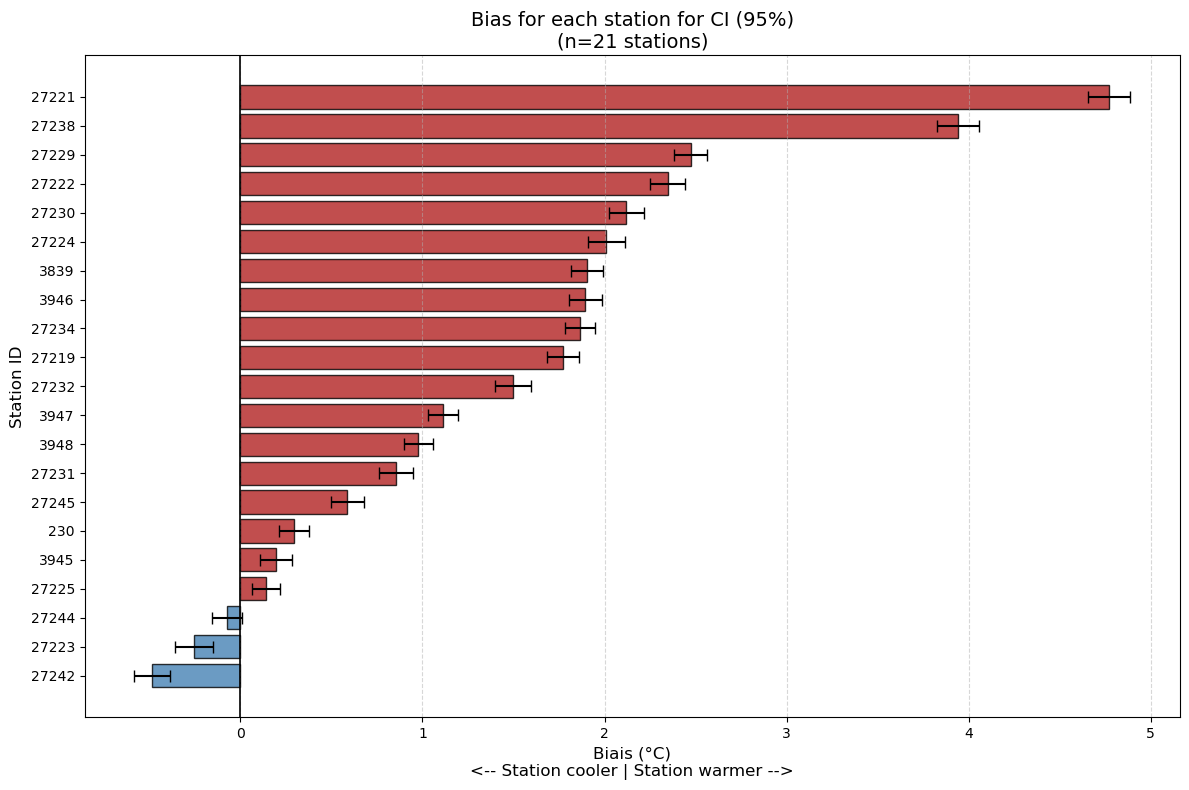

In [29]:
import matplotlib.pyplot as plt

stats_transposed = correlation_with_ndvi.T

stats_clean = stats_transposed.drop('Mean_stations', errors='ignore')
stats_sorted = stats_clean.sort_values(by='Bias')

plt.figure(figsize=(12, 8))

# Sort by bias value
colors = ['firebrick' if x > 0 else 'steelblue' for x in stats_sorted['Bias']]

plt.barh(stats_sorted.index.astype(str), stats_sorted['Bias'], 
         xerr=stats_sorted['CI'],  
         capsize=4,                
         color=colors, alpha=0.8, edgecolor='black')

plt.axvline(0, color='black', linestyle='-', linewidth=1.2) # Ligne zéro
plt.title(f'Bias for each station for CI (95%)\n(n={len(stats_sorted)} stations)', fontsize=14)
plt.xlabel('Biais (°C)\n<-- Station cooler | Station warmer -->', fontsize=12)
plt.ylabel('Station ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_115552\4233728628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='Station', y='Error', palette="viridis")


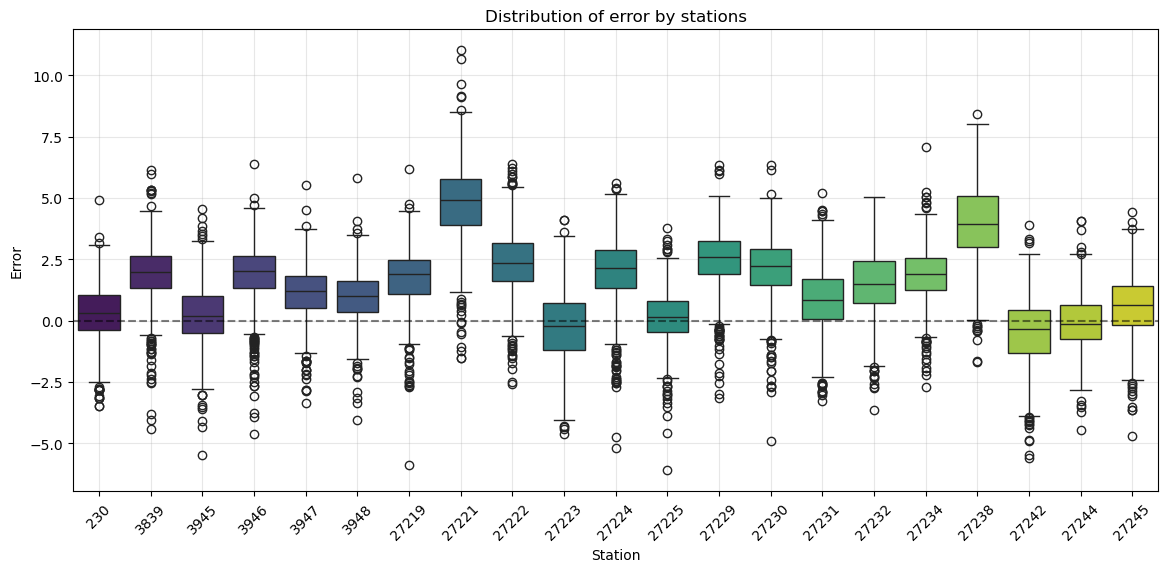

In [30]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_analysis, x='Station', y='Error', palette="viridis")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Distribution of error by stations")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

We see that the stations are almost always warmer than the ERA5-Land model except stations : 27244, 27223 and 27242. 

Let's see the nature of these stations (rural/urban)

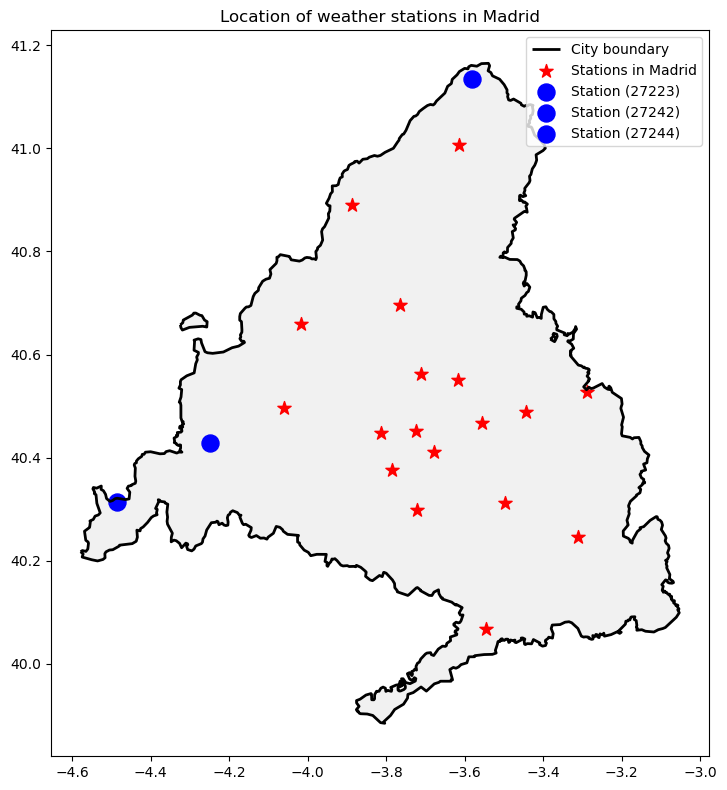

In [31]:
selected_station = stations_in_city_gdf.iloc[9]
selected_station2 = stations_in_city_gdf.iloc[18]
selected_station3 = stations_in_city_gdf.iloc[19]

selected_station_gdf = gpd.GeoDataFrame([selected_station], crs=stations_in_city_gdf.crs)
selected_station_STAID = selected_station['STAID']
selected_station_gdf2 = gpd.GeoDataFrame([selected_station2], crs=stations_in_city_gdf.crs)
selected_station_STAID2 = selected_station2['STAID']
selected_station_gdf3 = gpd.GeoDataFrame([selected_station3], crs=stations_in_city_gdf.crs)
selected_station_STAID3 = selected_station3['STAID']

fig, ax = plt.subplots(figsize=(10, 8))

one_city_gdf.boundary.plot(ax=ax, color='black', linewidth=2, label='City boundary')
one_city_gdf.plot(ax=ax, alpha=0.3, color='lightgray')

stations_in_city_gdf.plot(ax=ax, color='red', markersize=100, marker='*', label=f'Stations in {cityname}')
selected_station_gdf.plot(ax=ax, color='blue', markersize=150, marker='o', label=f'Station ({selected_station_STAID})')
selected_station_gdf2.plot(ax=ax, color='blue', markersize=150, marker='o', label=f'Station ({selected_station_STAID2})')
selected_station_gdf3.plot(ax=ax, color='blue', markersize=150, marker='o', label=f'Station ({selected_station_STAID3})')

plt.legend()
plt.title(f"Location of weather stations in {cityname}")
plt.tight_layout()
plt.show()

As we see here, the three stations are far from the center of the city, which makes it legitimate to conclude that they are in the rural areas.

(It explains why in our "one station" case, we had a positive correlation)

C:\Users\moham\AppData\Local\Temp\ipykernel_115552\1425377870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_analysis, x='Season', y='Error', inner="quartile", palette="coolwarm")


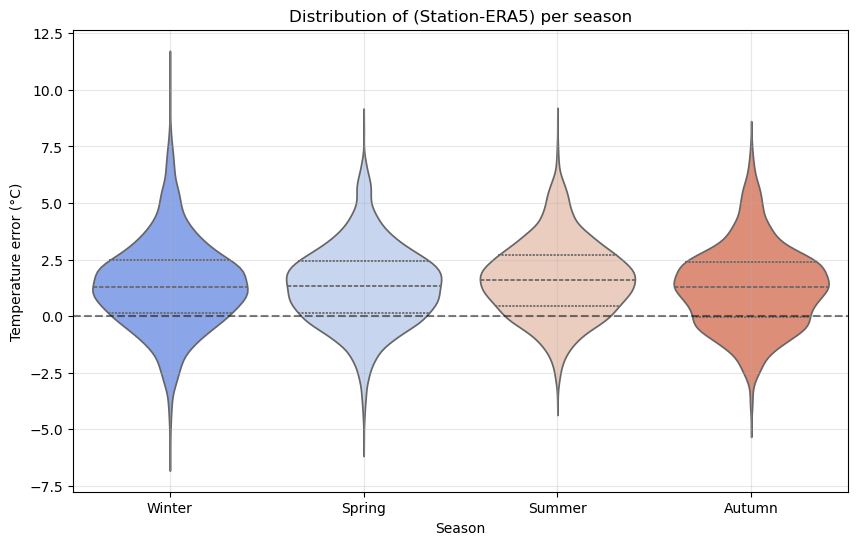

In [32]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_analysis, x='Season', y='Error', inner="quartile", palette="coolwarm")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Distribution of (Station-ERA5) per season")
plt.ylabel("Temperature error (°C)")
plt.grid(True, alpha=0.3)
plt.show()

We see that the bias (mean of discrepancies) is slightly bigger in the summer than the other seasons. This has given us the idea to restrict the study only to summer for the potential UHI effect.

             Bias      RMSE  Mean_NDVI  HGHT        Lat       Lon
Station                                                          
230      0.294517  1.166791   0.535713   667  40.411667 -3.678056
3839     1.904889  2.271932   0.531345   607  40.488333 -3.443333
3945     0.195731  1.251105   0.103135  1004  40.695833 -3.765000
3946     1.893727  2.270107   0.512875   609  40.466667 -3.555556
3947     1.112443  1.574714   0.133925   690  40.375556 -3.785833


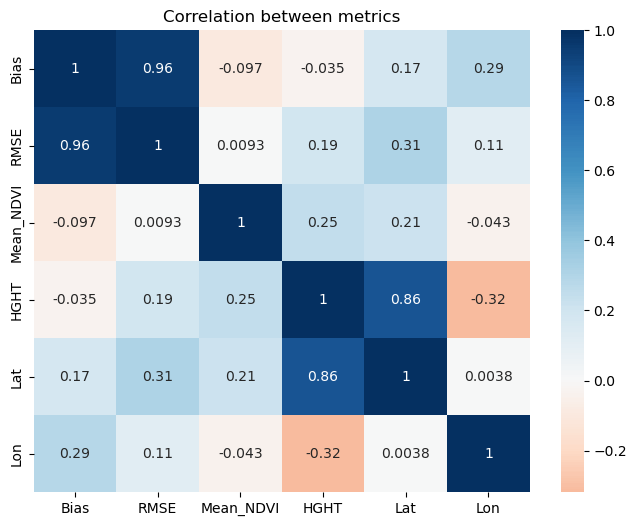

In [33]:
station_meta = stations_gdf[['STAID', 'HGHT']].set_index('STAID')

station_meta['Lat'] = stations_gdf.geometry.y.values
station_meta['Lon'] = stations_gdf.geometry.x.values

station_perf = df_analysis.groupby('Station').agg({
    'Error': ['mean', lambda x: np.sqrt((x**2).mean())], # Bias et RMSE
    'NDVI': 'mean' # NDVI moyen sur la période
})
station_perf.columns = ['Bias', 'RMSE', 'Mean_NDVI']
explanatory_df = station_perf.join(station_meta)
print(explanatory_df.head())

plt.figure(figsize=(8, 6))
sns.heatmap(explanatory_df.corr(), annot=True, cmap='RdBu', center=0)
plt.title("Correlation between metrics")
plt.show()

## With restriction on summer

In [34]:
station_discreptancies_by_quarter = pd.DataFrame({})
def transform_daily_into_season_only(discrepancies_daily, season):
    mean_discrepancies_by_quarter = pd.Series(dtype=float)
    valuesbyquarter = {}
    for date in discrepancies_daily.keys():
        year=date.year;month=date.month
        periodOfTime = quarter2timeperiod(year, quarter(month))
        new_date=pd.to_datetime(periodOfTime.split("_")[1])
        if quarter(month) in season:
            if new_date in mean_discrepancies_by_quarter.keys() and not np.isnan(discrepancies_daily[date]):
                valuesbyquarter[new_date].append(discrepancies_daily[date])
                mean_discrepancies_by_quarter[new_date]=np.mean(valuesbyquarter[new_date])
            elif new_date not in mean_discrepancies_by_quarter.keys() and not np.isnan(discrepancies_daily[date]):
                valuesbyquarter[new_date]=[discrepancies_daily[date]]
                mean_discrepancies_by_quarter[new_date]=discrepancies_daily[date]

    mean_discrepancies_by_quarter.sort_index()
    return mean_discrepancies_by_quarter
for staid in staids:
    station_discreptancies_by_quarter[staid]=transform_daily_into_season_only(discreptancies_by_stations[staid], [1,2,3,4])
station_discreptancies_by_quarter['Mean_stations']=transform_daily_into_season_only(discreptancies_by_stations['Mean_stations'], [1,2,3,4])

station_discreptancies_by_quarter.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
2020-03-01,-0.031956,1.055461,-0.378157,1.333767,0.752138,0.507897,1.611813,4.617910,2.189812,-0.272971,...,1.799363,1.331406,0.717705,1.107694,1.250319,3.534250,-1.032164,-0.168427,0.346457,1.023505
2020-06-01,0.725781,1.945519,-0.223270,2.349689,1.318142,0.970254,1.880451,4.744532,1.883920,-0.315440,...,2.440427,1.999559,1.562050,1.353142,1.988264,3.780429,-0.715566,-0.249782,0.185868,1.415838
2020-09-01,-0.059874,1.516615,-0.255422,2.062318,1.443334,0.962157,0.896992,4.473071,1.700148,-0.043726,...,2.118016,1.656187,0.448646,1.383334,1.324492,2.884634,0.224037,-0.170885,0.528763,1.166511
2020-12-01,-0.827890,-1.137561,-1.639252,-0.934045,-0.985507,-1.259726,-1.519882,2.533405,0.531500,-3.261664,...,-0.175061,-1.153085,-0.274866,-0.485507,-1.042734,1.182233,-1.617892,-0.974554,-1.075336,-0.773998
2021-12-01,0.674965,2.252197,1.337363,2.108027,1.984828,1.760194,2.510160,5.165492,3.405802,-0.175787,...,2.902165,2.796718,0.832263,2.610754,2.104545,4.620306,0.186094,1.261780,1.844120,2.095596


In [35]:
correlations= {}
bias = {}
mse = {}
std = {}
ci = {}
# 1.96* (std/np.sqrt(len(df)))

for staid in staids:
    bias[staid]= station_discreptancies_by_quarter[staid].mean()
    mse[staid]= np.mean(station_discreptancies_by_quarter[staid]**2)
    std[staid] = station_discreptancies_by_quarter[staid].std() 
    ci[staid]=1.96 * (std[staid]/np.sqrt(len(station_discreptancies_by_quarter[staid])))
    correlations[staid]= station_discreptancies_by_quarter[staid].corr(ndvi_stations_df[staid])
bias['Mean_stations']= station_discreptancies_by_quarter[staid].mean()
mse['Mean_stations']= np.mean(station_discreptancies_by_quarter[staid]**2)
std['Mean_stations'] = station_discreptancies_by_quarter[staid].std() 
correlations['Mean_stations']= station_discreptancies_by_quarter[staid].corr(ndvi_stations_df['Mean_stations'])
ci['Mean_stations']=1.96 * (std['Mean_stations']/np.sqrt(len(station_discreptancies_by_quarter['Mean_stations'])))

correlations['Mean_stations']= station_discreptancies_by_quarter['Mean_stations'].corr(mean_ndvi_time_series)
correlation_with_ndvi = pd.DataFrame([bias, correlations, mse, std, ci])
correlation_with_ndvi.index = ['Bias', 'Correlation bias with NDVI', 'MSE', 'STD', 'CI']
correlation_with_ndvi.head()

,230,3839,3945,3946,3947,3948,27219,27221,27222,27223,...,27229,27230,27231,27232,27234,27238,27242,27244,27245,Mean_stations
Bias,0.252183,1.742967,0.109231,1.775321,1.050153,0.872939,1.525973,4.660338,2.238813,-0.345641,...,2.342022,1.960527,0.814783,1.399622,1.704320,3.754004,-0.483146,-0.095640,0.535973,0.535973
Correlation bias with NDVI,-0.569489,0.003507,0.128108,-0.276982,-0.036028,-0.072768,-0.220213,-0.054258,0.169111,-0.062770,...,-0.047995,-0.159013,-0.171129,0.113891,-0.210422,0.452131,-0.365261,0.131104,0.078879,0.050868
MSE,0.356067,3.791960,0.467555,3.868410,1.494565,1.150062,3.104909,22.160988,5.471113,1.114114,...,6.141794,4.783493,1.181254,2.369904,3.661203,14.750753,0.483381,0.241988,0.659022,0.659022
STD,0.558542,0.896824,0.697136,0.874313,0.646420,0.643358,0.909982,0.686820,0.699583,1.030027,...,0.836964,1.001240,0.742883,0.662086,0.898293,0.837909,0.516347,0.498361,0.629713,0.629713
CI,0.273686,0.439444,0.341597,0.428413,0.316746,0.315245,0.445891,0.336542,0.342796,0.504713,...,0.410113,0.490607,0.364012,0.324422,0.440164,0.410575,0.253010,0.244197,0.308560,0.308560


We found out that correlation with NDVI during summer is very important and negative (and the bias is positive except for our 3 exceptions in the rural part), this confirms that the UHI effect is important during summer and it is the main responsible for this discrepancies between ERA5-Land model and the stations measures.

We see that the altitude doesn't have much effect on our dicrepancies between the datasets. So the UHI effect on summer is the main responsible for these discrepancies.

## 2. Our answer for this last week



Objective : *summarize our findings and propose explanatory models or adjustments to existing data.*

In [ ]:
all_data_list = []
stations_list = [c for c in stations_df.columns if 'Mean' not in str(c)]

for staid in stations_list:
    if staid not in ndvi_stations_df.columns: continue
    
    temp_station = stations_df['Mean_stations']
    era5_for_station = era5_timed_series_by_stations[staid]
    ndvi_for_station = ndvi_stations_df[staid]
    ndvi_daily = ndvi_for_station.reindex(temp_station.index, method='ffill')

    df_temp = pd.DataFrame({
        'Date': temp_station.index,
        'Station_ID': staid,
        'Station_TX': temp_station.values,
        'ERA5_TX': era5_for_station.reindex(temp_station.index).values,
        'NDVI': ndvi_daily.values
    })
    all_data_list.append(df_temp)

df_final = pd.concat(all_data_list, ignore_index=False)
df_sim = df_final.dropna()
df_analysis['Date'] = pd.to_datetime(df_analysis['Date']) 
df_analysis['Month'] = df_analysis['Date'].dt.month
def get_season(month):
    """Détermine la saison à partir du mois (ajustement de votre fonction pour les mois 1,2,3...12)"""
    # Mettez à jour les mois pour qu'ils correspondent aux trimestres que vous utilisez
    if 1<=month<=3: return 'Spring' # T1 (Dec-Fev ou Jan-Mars) - On va garder le Printemps comme nom pour la référence
    elif 4<=month<=6: return 'Summer'
    elif 7<=month<=9: return 'Autumn'
    else: return 'Winter' # 10, 11, 12

df_analysis['Season'] = df_analysis['Month'].apply(get_season)
df_sim = df_sim.set_index('Date')

## First method : multivariate linear regression

In [177]:
df_sim['Date'] = pd.to_datetime(df_sim['Date']) 
df_sim['Month'] = df_sim['Date'].dt.month

def get_season(month):
    if 1<=month<=3: return 'Spring'
    elif 4<=month<=6: return 'Summer'
    elif 7<=month<=9: return 'Autumn'
    else: return 'Winter'

df_sim['Season'] = df_sim['Month'].apply(get_season)

# Joindre les métadonnées (Lon, Lat) au DataFrame journalier
# station_meta est supposé être un DataFrame indexé par STAID (int)
df_model_daily = df_sim.merge(
    station_meta[['Lon', 'Lat']].astype(float),
    left_on='Station_ID',
    right_index=True
)
df_model_daily.rename(columns={'Lon': 'Longitude', 'Lat': 'Latitude'}, inplace=True)

# Créer le DataFrame agrégé par station/saison (pour le FIT du modèle)
data_to_model = df_model_daily.groupby(['Station_ID', 'Season']).agg({
    'Bias': 'mean',
    'NDVI': 'mean',
    'Longitude': 'first',
    'Latitude': 'first'
}).reset_index()

# --- 3. DÉFINITION DES VARIABLES OLS ---

dummy_seasons = pd.get_dummies(data_to_model['Season'], drop_first=False, prefix='Season')
dummy_seasons = dummy_seasons.drop(columns=['Season_Spring'])
data_model_final = pd.concat([data_to_model, dummy_seasons], axis=1)

Y = data_model_final['Bias'].astype(float)
# X inclut NDVI, Longitude, Latitude et les dummies saisonnières (Spring est la référence)
X = data_model_final[['NDVI', 'Longitude', 'Latitude', 'Season_Summer', 'Season_Autumn', 'Season_Winter']]

X = X.astype(float)
X = sm.add_constant(X)
X = X.fillna(X.mean())
Y = Y.fillna(Y.mean())

# --- 4. EXÉCUTION DE LA RÉGRESSION OLS ET PRÉDICTION ---

model = sm.OLS(Y, X).fit()

# 1. Calculer le biais moyen prédit pour chaque groupe Station/Saison (y_pred)
data_model_final['Bias_Predicted'] = model.fittedvalues

# 2. Créer le dictionnaire de mappage (Station_ID, Season) -> Bias_Predicted
bias_map = data_model_final.set_index(['Station_ID', 'Season'])['Bias_Predicted'].to_dict()

# 3. Mapper le biais prédit sur les données journalières
df_prediction_daily = df_model_daily.copy()
df_prediction_daily['Key'] = list(zip(df_prediction_daily['Station_ID'], df_prediction_daily['Season']))
df_prediction_daily['Predicted_Mean_Bias'] = df_prediction_daily['Key'].map(bias_map)

# 4. Calculer la TEMPÉRATURE PRÉDITE DE LA STATION
# Station_TX_Predicted = ERA5_TX_Original + Predicted_Mean_Bias
df_prediction_daily['Station_TX_Predicted'] = df_prediction_daily['ERA5_TX'] + df_prediction_daily['Predicted_Mean_Bias']

# 5. Calculer la SÉRIE TEMPORELLE FINALE (Moyenne journalière des prédictions)
final_predicted_time_series = df_prediction_daily.groupby('Date')['Station_TX_Predicted'].mean().rename('Predicted Mean Station TX (Corrected ERA5)')

print("\nLes premières lignes de la série temporelle prédite sont :")
print(final_predicted_time_series.head())
print("\n" + "="*50)
print("RÉSUMÉ DES RÉSULTATS DE LA RÉGRESSION LINÉAIRE (OLS):")
print("="*50)
print(model.summary())


Les premières lignes de la série temporelle prédite sont :
Date
2020-03-01    13.120914
2020-03-02    11.355596
2020-03-03    14.955230
2020-03-04    16.764928
2020-03-05    15.005012
Name: Predicted Mean Station TX (Corrected ERA5), dtype: float64

RÉSUMÉ DES RÉSULTATS DE LA RÉGRESSION LINÉAIRE (OLS):
                            OLS Regression Results                            
Dep. Variable:                   Bias   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     2.059
Date:                Wed, 03 Dec 2025   Prob (F-statistic):             0.0678
Time:                        18:03:12   Log-Likelihood:                -136.99
No. Observations:                  84   AIC:                             288.0
Df Residuals:                      77   BIC:                             305.0
Df Model:                           6                          

C:\Users\moham\AppData\Local\Temp\ipykernel_115552\4219922615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim['Date'] = pd.to_datetime(df_sim['Date'])
C:\Users\moham\AppData\Local\Temp\ipykernel_115552\4219922615.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim['Month'] = df_sim['Date'].dt.month
C:\Users\moham\AppData\Local\Temp\ipykernel_115552\4219922615.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

In [181]:
# --- PLOTTING LOGIC (Using corrected aggregation) ---

# 1. Predicted Mean Bias (y_pred is model.fittedvalues)
data_model_final['Bias_Predicted'] = model.fittedvalues

# 2. Create the mapping dictionary (Station_ID, Season) -> Bias_Predicted
bias_map = data_model_final.set_index(['Station_ID', 'Season'])['Bias_Predicted'].to_dict()

# 3. Map the predicted mean bias back to the daily data (df_model_daily)
df_prediction_daily = df_model_daily.copy()
df_prediction_daily['Key'] = list(zip(df_prediction_daily['Station_ID'], df_prediction_daily['Season']))
df_prediction_daily['Predicted_Mean_Bias'] = df_prediction_daily['Key'].map(bias_map)

# 4. Calculate the Predicted Station TX (Corrected ERA5 TX)
df_prediction_daily['Station_TX_Predicted'] = df_prediction_daily['ERA5_TX'] + df_prediction_daily['Predicted_Mean_Bias']

# 5. Calculate the Final Predicted Time Series (daily average across all stations)
final_predicted_time_series = df_prediction_daily.groupby('Date')['Station_TX_Predicted'].mean().rename('Corrected ERA5 (OLS Model)')

# 6. Calculate the daily means for the reference series
actual_mean_station_tx = df_prediction_daily.groupby('Date')['Station_TX'].mean().rename('Reality (Station)')
original_mean_era5_tx = df_prediction_daily.groupby('Date')['ERA5_TX'].mean().rename('Original ERA5 (Before)')

# 7. Combine all three series for plotting and limit to 200 days
df_comparison_plot = pd.DataFrame({
    'Reality (Station)': actual_mean_station_tx,
    'Original ERA5 (Before)': original_mean_era5_tx,
    'Corrected ERA5 (OLS Model)': final_predicted_time_series
}).dropna()

num_days = 365
df_plot_subset = df_comparison_plot.head(num_days)



RMSE : 0.9259572905704451


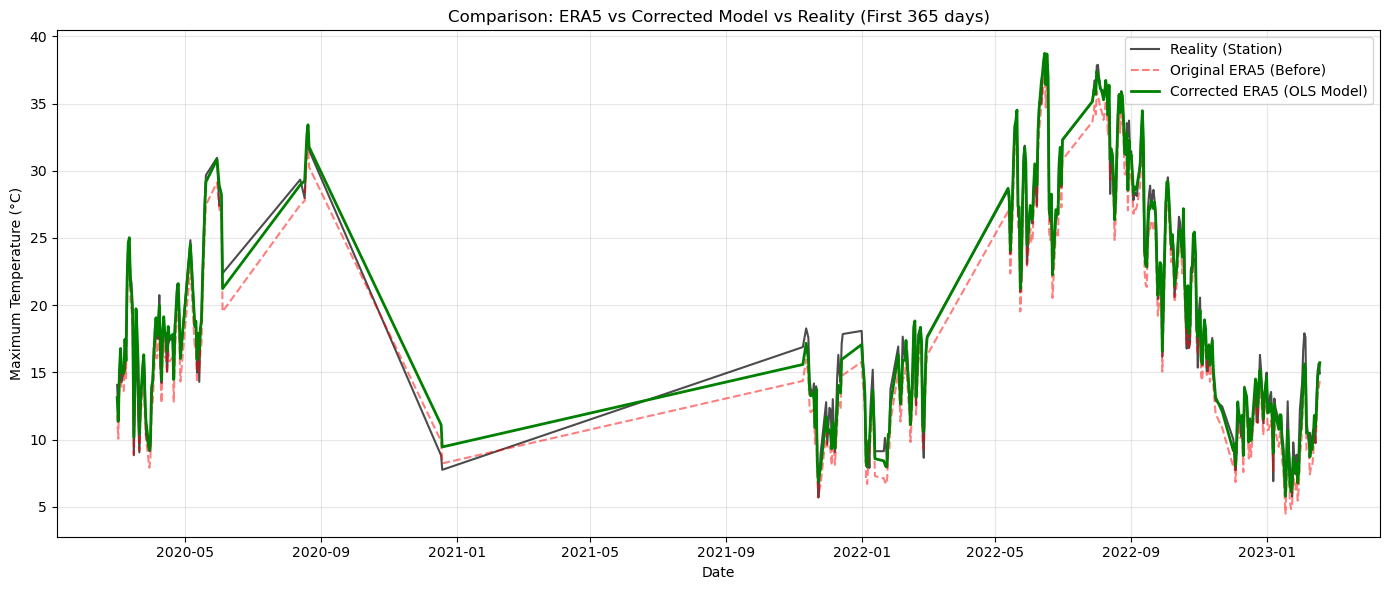

In [185]:
# 8. Generate the plot
plt.figure(figsize=(14, 6))
plt.plot(df_plot_subset.index, df_plot_subset['Reality (Station)'], 
         label='Reality (Station)', color='black', alpha=0.7)
plt.plot(df_plot_subset.index, df_plot_subset['Original ERA5 (Before)'], 
         label='Original ERA5 (Before)', color='red', linestyle='--', alpha=0.5)
plt.plot(df_plot_subset.index, df_plot_subset['Corrected ERA5 (OLS Model)'], 
         label='Corrected ERA5 (OLS Model)', color='green', linewidth=2)

# Affichage des résultats
plt.title(f'Comparison: ERA5 vs Corrected Model vs Reality (First {len(df_plot_subset)} days)')
plt.ylabel('Maximum Temperature (°C)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"RMSE : {np.sqrt(np.mean((df_comparison_plot['Reality (Station)']-df_comparison_plot['Corrected ERA5 (OLS Model)'])**2))}")

## Second method : using RandomForest

In [187]:
df_final['Month_Num'] = df_final['Date'].dt.month

df_final['Month_Sin'] = np.sin(2 * np.pi * df_final['Month_Num']/12)
df_final['Month_Cos'] = np.cos(2 * np.pi * df_final['Month_Num']/12)

def get_season(month):
    if month in [1, 2,3]: return 'Winter'
    elif month in [4, 5, 6]: return 'Spring'
    elif month in [7, 8, 9]: return 'Summer'
    else: return 'Autumn'

df_final['Season'] = df_final['Month_Num'].apply(get_season)

df_model = df_final.dropna().copy()

features = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
target = 'Station_TX'

rf_global = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
rf_global.fit(df_model[features], df_model[target])

df_model['Corrected_TX'] = rf_global.predict(df_model[features])

# Calcul des erreurs
df_model['Error_ERA5'] = df_model['Station_TX'] - df_model['ERA5_TX']
df_model['Error_Corrected'] = df_model['Station_TX'] - df_model['Corrected_TX']



C:\Users\moham\AppData\Local\Temp\ipykernel_115552\2343573347.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seasonal_stats = df_model.groupby('Season').apply(


   Season  RMSE_ERA5  RMSE_Corrected   Count      Gain
0  Autumn   2.245744        1.294908  2961.0  0.950836
1  Spring   2.434039        1.122949  3927.0  1.311089
2  Summer   2.245874        1.058878  3402.0  1.186996
3  Winter   2.289246        1.308345  4473.0  0.980901


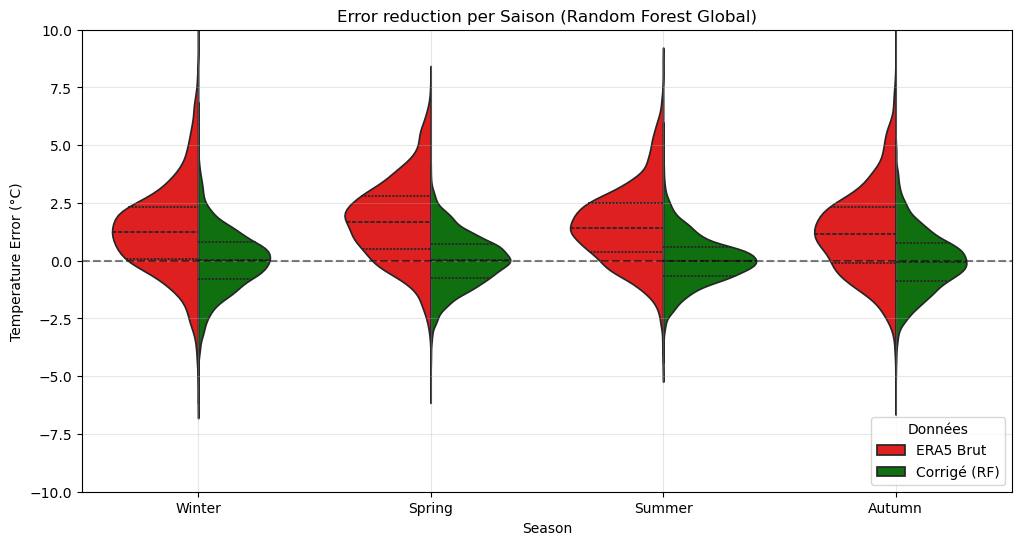

In [188]:
seasonal_stats = df_model.groupby('Season').apply(
    lambda x: pd.Series({
        'RMSE_ERA5': np.sqrt(mean_squared_error(x['Station_TX'], x['ERA5_TX'])),
        'RMSE_Corrected': np.sqrt(mean_squared_error(x['Station_TX'], x['Corrected_TX'])),
        'Count': len(x)
    })
).reset_index()

seasonal_stats['Gain'] = seasonal_stats['RMSE_ERA5'] - seasonal_stats['RMSE_Corrected']
print(seasonal_stats)

plt.figure(figsize=(12, 6))

# Ordre des saisons pour l'affichage
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df_model['Season'] = pd.Categorical(df_model['Season'], categories=season_order, ordered=True)

# Création d'un DataFrame long pour seaborn (plus facile à tracer)
df_viz = pd.melt(df_model, 
                 id_vars=['Season'], 
                 value_vars=['Error_ERA5', 'Error_Corrected'], 
                 var_name='Model', value_name='Error')

# Renommer pour la légende
df_viz['Model'] = df_viz['Model'].replace({'Error_ERA5': 'ERA5 Brut', 'Error_Corrected': 'Corrigé (RF)'})

# Violin Plot comparatif
sns.violinplot(data=df_viz, x='Season', y='Error', hue='Model', split=True, inner='quartile', palette={'ERA5 Brut': 'red', 'Corrigé (RF)': 'green'})

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Error reduction per Saison (Random Forest Global)")
plt.ylabel("Temperature Error (°C)")
plt.ylim(-10, 10) # Pour zoomer sur l'essentiel
plt.legend(title='Données')
plt.grid(True, alpha=0.3)
plt.show()

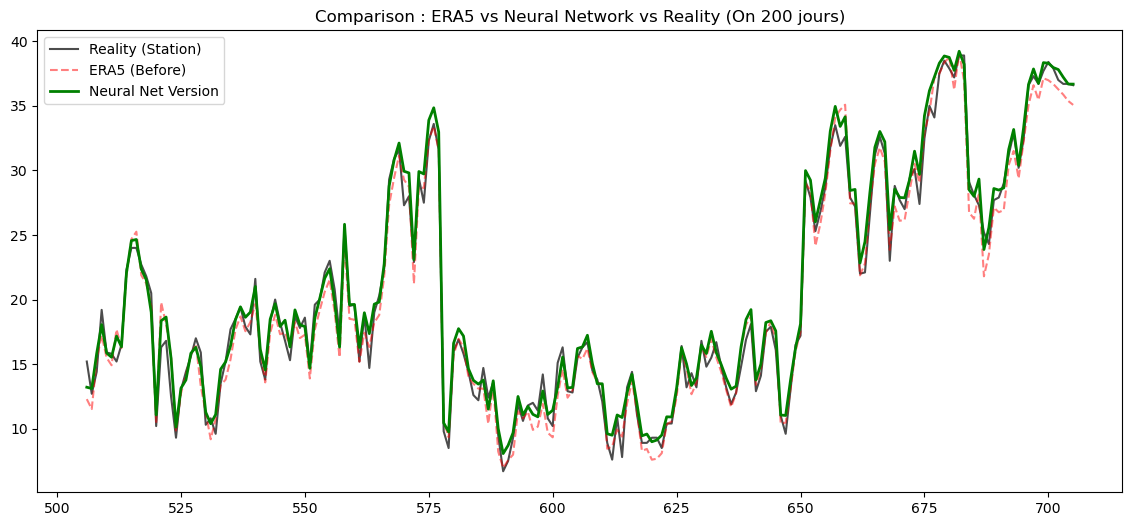

RMSE : 1.2036463582990515


In [192]:
num_days=200
plt.figure(figsize=(14, 6))
plt.plot(df_model['Station_TX'][:num_days], label='Reality (Station)', color='black', alpha=0.7)
plt.plot(df_model['ERA5_TX'][:num_days], label='ERA5 (Before)', color='red', linestyle='--', alpha=0.5)
plt.plot(df_model['Corrected_TX'][:num_days], label='Neural Net Version', color='green', linewidth=2)
plt.title(f'Comparison : ERA5 vs Neural Network vs Reality (On {num_days} jours)')
plt.legend()
plt.show()

print(f"RMSE : {np.sqrt(np.mean((df_model['Station_TX']-df_model['Corrected_TX'])**2))}")

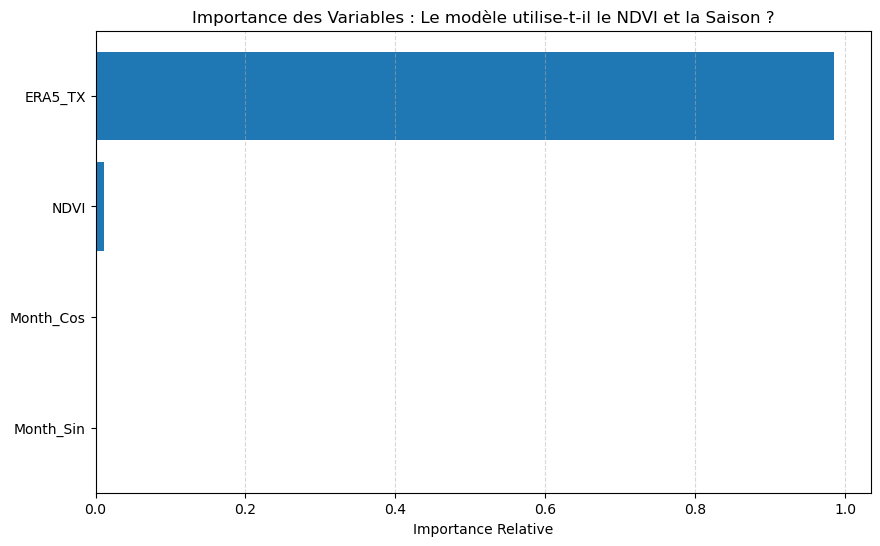

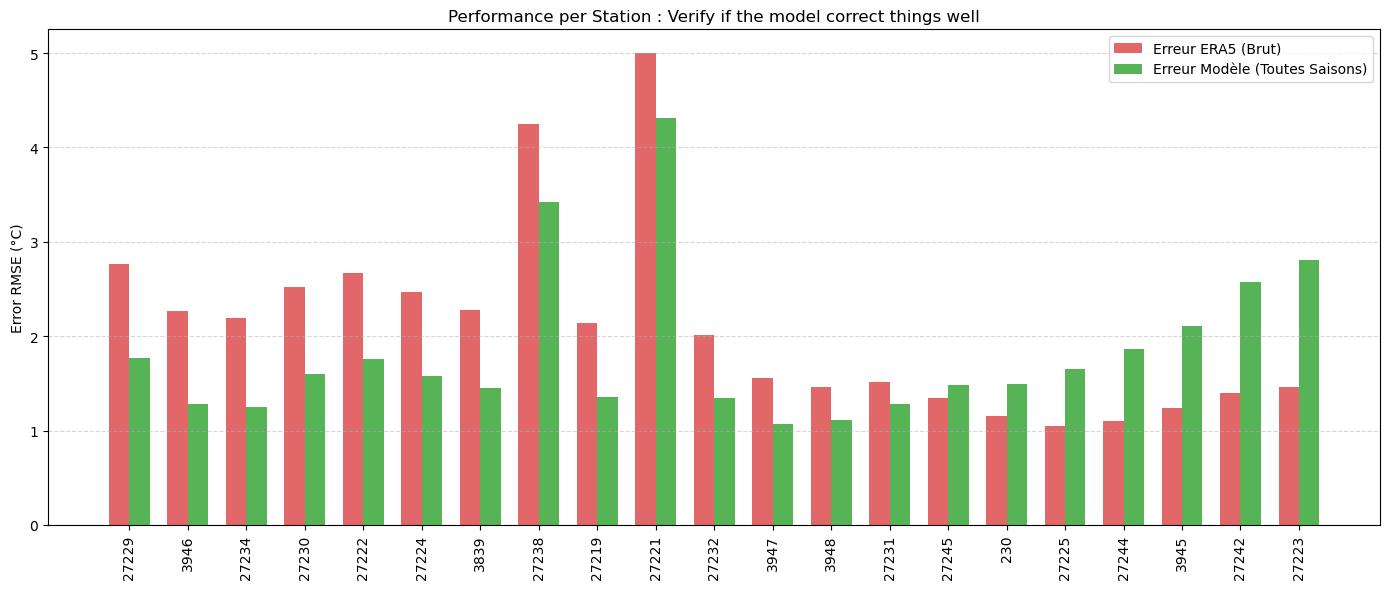

Mean Gain 'All Seasons' : 0.25°C


In [68]:
importances = rf_global.feature_importances_
feature_names = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importance des Variables : Le modèle utilise-t-il le NDVI et la Saison ?')
plt.barh(range(len(indices)), importances[indices], color='#1f77b4', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Relative')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

results_cv_season = []
features_season = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
stations_list = df_model['Station_ID'].unique()

for test_station in stations_list:
    # Séparation
    train_data = df_model[df_model['Station_ID'] != test_station]
    test_data = df_model[df_model['Station_ID'] == test_station]
    
    if len(test_data) == 0: continue

    # Entraînement temporaire
    model_cv = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    model_cv.fit(train_data[features_season], train_data['Station_TX'])
    
    # Prédiction
    pred_cv = model_cv.predict(test_data[features_season])
    
    # Scores
    rmse_era5 = np.sqrt(mean_squared_error(test_data['Station_TX'], test_data['ERA5_TX']))
    rmse_model = np.sqrt(mean_squared_error(test_data['Station_TX'], pred_cv))
    
    results_cv_season.append({
        'Station': test_station,
        'RMSE_ERA5': rmse_era5,
        'RMSE_Corrected': rmse_model,
        'Gain': rmse_era5 - rmse_model
    })

df_res_season = pd.DataFrame(results_cv_season).sort_values('Gain', ascending=False)

# Tracé du graphique
plt.figure(figsize=(14, 6))
x = np.arange(len(df_res_season))
width = 0.35

plt.bar(x - width/2, df_res_season['RMSE_ERA5'], width, label='Erreur ERA5 (Brut)', color='#d62728', alpha=0.7)
plt.bar(x + width/2, df_res_season['RMSE_Corrected'], width, label='Erreur Modèle (Toutes Saisons)', color='#2ca02c', alpha=0.8)

plt.xticks(x, df_res_season['Station'], rotation=90)
plt.ylabel('Error RMSE (°C)')
plt.title('Performance per Station : Verify if the model correct things well')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Mean Gain 'All Seasons' : {df_res_season['Gain'].mean():.2f}°C")

## Using a Neural Network

In [228]:
# Setuping the datas
features = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
target = 'Station_TX'

# Nettoyage
df_nn = df_final.dropna().copy()

X = df_nn[features].values
y = df_nn[target].values

print(df_nn['ERA5_TX'])

506      12.287079
507      11.518280
508      15.338837
509      17.218597
510      15.493073
           ...    
25384    31.530304
25385    34.282593
25386    31.609039
25387    30.368134
25388    31.131897
Name: ERA5_TX, Length: 14763, dtype: float32


In [255]:
# Setuping the datas
features = ['ERA5_TX', 'NDVI', 'Month_Sin', 'Month_Cos']
target = 'Station_TX'

# Nettoyage
df_nn = df_final.dropna().copy()

X = df_nn[features].values
y = df_nn[target].values

In [257]:
from tqdm import tqdm
import os

# ==========================================
# 1. SELECTION DE TOUTES LES STATIONS (ESPAGNE)
# ==========================================

print("Chargement de la carte et des stations...")
# Géométrie de l'Espagne
spain_gdf = gadm_gdf[(gadm_gdf.GID_0 == "ESP")& (gadm_gdf.NAME_2 != "Madrid")].dissolve()

# Chargement du fichier de métadonnées des stations
stations_df = pd.read_csv(stations_filepath, skiprows=17, skipinitialspace=True)
stations_df['LAT_decimal'] = stations_df['LAT'].apply(dms_to_decimal)
stations_df['LON_decimal'] = stations_df['LON'].apply(dms_to_decimal)

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df['LON_decimal'], stations_df['LAT_decimal']),
    crs="EPSG:4326"
)

# Filtre : on ne garde que les stations qui sont en Espagne
stations_in_spain = stations_gdf[stations_gdf.within(spain_gdf.geometry.iloc[0])]
print(f"Stations trouvées en Espagne : {len(stations_in_spain)}")

# ==========================================
# 2. CREATION DU DATASET MASSIF (X, y)
# ==========================================

X_list = []
y_list = []

# Période d'étude (à adapter selon vos fichiers ERA5 disponibles)
start_date = pd.Timestamp("2020-01-01")
end_date = pd.Timestamp("2023-12-31")

print("Construction du dataset d'entraînement...")

for idx, station in tqdm(stations_in_spain.iterrows(), total=len(stations_in_spain)):
    try:
        # A. Charger la donnée Station (Vérité Terrain)
        staid = station['STAID']
        fpath = eca_tx_datafolder + f"TX_STAID{staid:06d}.txt"
        
        if not os.path.exists(fpath): continue
            
        df_s = pd.read_csv(fpath, skiprows=20, skipinitialspace=True)
        # On ne garde que les données valides (Q_TX = 0)
        df_s = df_s[df_s['Q_TX'] == 0]
        df_s['DATE'] = pd.to_datetime(df_s['DATE'], format='%Y%m%d')
        df_s = df_s.set_index('DATE').sort_index()
        
        # Filtrer sur la période commune
        mask_date = (df_s.index >= start_date) & (df_s.index <= end_date)
        df_s = df_s.loc[mask_date]
        
        if len(df_s) < 50: continue # On ignore les stations avec trop peu de données
        
        station_series = df_s['TX'] / 10.0 # Conversion en °C
        station_series.name = 'Station_TX'
        
        # B. Extraire la donnée ERA5 (Input du modèle)
        # On utilise les coordonnées de la station pour chercher le point ERA5 le plus proche
        lat_s, lon_s = station.geometry.y, station.geometry.x
        
        # Selection 'nearest' dans le dataset xarray
        era5_point = ds[datavar].sel(latitude=lat_s, longitude=lon_s, method="nearest")
        era5_series = era5_point.to_series() - 273.15 # Kelvin -> Celsius
        era5_series.name = 'ERA5_TX'
        
        # C. Fusionner et nettoyer (drop NaN)
        # On ne garde que les jours où on a les DEUX infos (Station ET ERA5)
        merged = pd.concat([station_series, era5_series], axis=1).dropna()
        
        if len(merged) == 0: continue

        # Ajout aux listes
        X_list.append(merged[['ERA5_TX']].values)
        y_list.append(merged[['Station_TX']].values)
        
    except Exception as e:
        continue

# Assemblage final
if len(X_list) > 0:
    X_all = np.vstack(X_list)
    y_all = np.vstack(y_list)
    print(f"\nDataset prêt : {X_all.shape[0]} points de données (jours * stations).")
else:
    print("Erreur : Aucun dataset n'a pu être créé. Vérifiez vos chemins et dates.")

# ==========================================
# 3. RESEAU DE NEURONES (DEEP LEARNING)
# ==========================================

if len(X_list) > 0:
    # Split Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

    # Standardisation (Essentiel pour les réseaux de neurones)
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Architecture du modèle
    # Plus profond que le précédent pour capturer les nuances de toutes les stations
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(), # Stabilise l'apprentissage
        Dropout(0.1),         # Evite le sur-apprentissage
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dense(1)              # Sortie : Température corrigée
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    print("Démarrage de l'entraînement...")
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=4096, # Grand batch size pour aller vite sur beaucoup de data
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluation
    loss, mae = model.evaluate(X_test_scaled, y_test)
    print(f"\nPerformance finale sur le Test Set - MAE: {mae:.4f} °C")

    

Chargement de la carte et des stations...
Stations trouvées en Espagne : 900
Construction du dataset d'entraînement...


100%|██████████| 900/900 [04:14<00:00,  3.53it/s]



Dataset prêt : 1143198 points de données (jours * stations).
Démarrage de l'entraînement...
Epoch 1/100
179/179 [==============================] - 6s 18ms/step - loss: 144.1962 - mae: 9.0969 - val_loss: 225.0688 - val_mae: 13.8674 - lr: 0.0010
Epoch 2/100
179/179 [==============================] - 3s 14ms/step - loss: 7.5711 - mae: 2.0790 - val_loss: 74.6781 - val_mae: 7.6415 - lr: 0.0010
Epoch 3/100
179/179 [==============================] - 3s 15ms/step - loss: 6.7780 - mae: 1.9460 - val_loss: 14.6125 - val_mae: 3.1478 - lr: 0.0010
Epoch 4/100
179/179 [==============================] - 3s 14ms/step - loss: 6.4437 - mae: 1.8854 - val_loss: 6.1361 - val_mae: 1.8323 - lr: 0.0010
Epoch 5/100
179/179 [==============================] - 3s 15ms/step - loss: 6.2457 - mae: 1.8473 - val_loss: 5.8412 - val_mae: 1.7659 - lr: 0.0010
Epoch 6/100
179/179 [==============================] - 3s 14ms/step - loss: 6.1151 - mae: 1.8214 - val_loss: 5.6867 - val_mae: 1.7318 - lr: 0.0010
Epoch 7/100
179/17

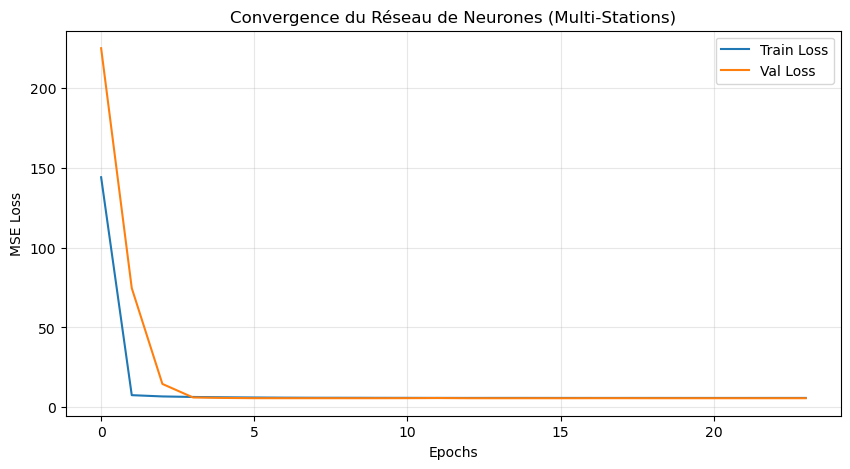

4/4 [==============================] - 0s 2ms/step


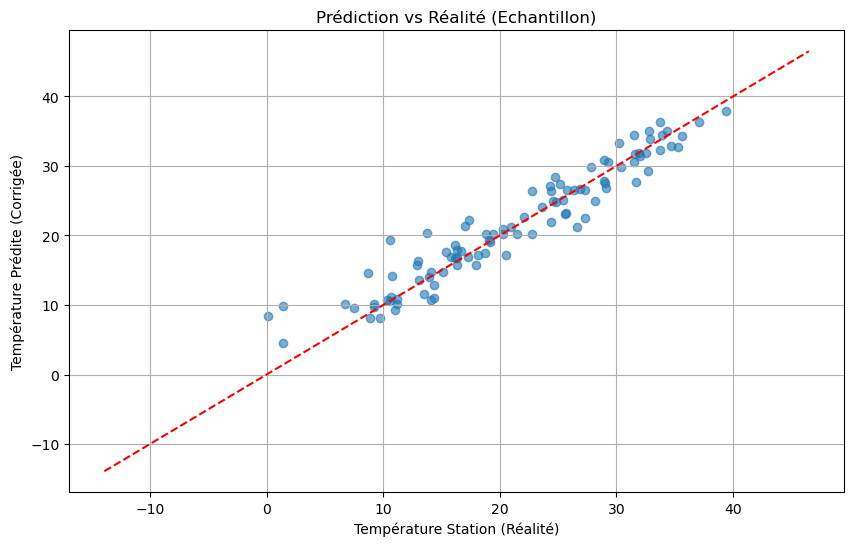

In [258]:
# Visualisation de la Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Convergence du Réseau de Neurones (Multi-Stations)")
plt.ylabel("MSE Loss")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualisation Prédiction vs Réalité (sur un sous-échantillon pour lisibilité)
plt.figure(figsize=(10, 6))
subset_n = 100
plt.scatter(y_test[:subset_n], model.predict(X_test_scaled[:subset_n]), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ligne parfaite
plt.xlabel("Température Station (Réalité)")
plt.ylabel("Température Prédite (Corrigée)")
plt.title("Prédiction vs Réalité (Echantillon)")
plt.grid()
plt.show()

In [259]:
print(stations_df[stations_df['STAID'].isin(staids)])
true = df_nn[['Station_TX']].values
y_pred = model.predict(scaler_X.transform(df_nn[['ERA5_TX']].values))

print(f"Bias : {(true - y_pred).mean()}")

      STAID      STANAME                                     CN        LAT  \
175     230  MADRID RETIRO                                 ES    +40:24:42   
1514   3839  TORREJON DE ARDOZ                             ES    +40:29:18   
1565   3945  COLMENAR VIEJO                                ES    +40:41:45   
1566   3946  MADRID AEROPUERTO                             ES    +40:28:00   
1567   3947  MADRID  CUATRO VIENTOS                        ES    +40:22:32   
1568   3948  GETAFE                                        ES    +40:17:57   
7840  27219  ARANJUEZ                                      ES    +40:04:01   
7842  27221  RASCAFRIA                                     ES    +40:53:22   
7843  27222  BUITRAGO DEL LOZOYA                           ES    +41:00:24   
7844  27223  SOMOSIERRA                                    ES    +41:08:08   
7845  27224  SAN SEBASTIAN DE LOS REYES                    ES    +40:33:00   
7846  27225  MADRID  EL GOLOSO                             ES   

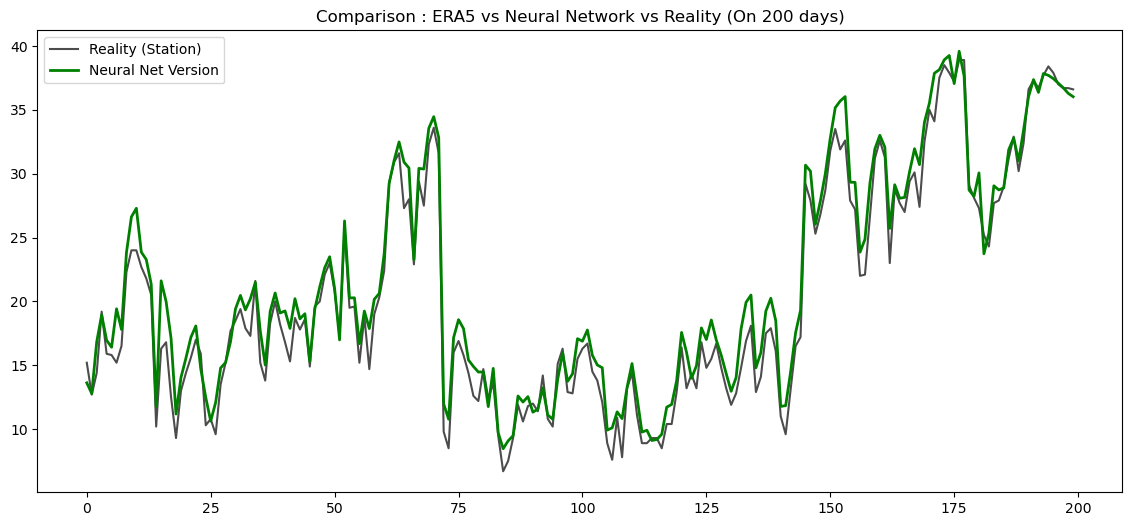

In [260]:
plt.figure(figsize=(14, 6))
num_days = 200
plt.plot(true[:num_days], label='Reality (Station)', color='black', alpha=0.7)
#plt.plot(X_test[:num_days, 0], label='ERA5 (Before)', color='red', linestyle='--', alpha=0.5)
plt.plot(y_pred[:num_days], label='Neural Net Version', color='green', linewidth=2)
plt.title(f'Comparison : ERA5 vs Neural Network vs Reality (On {num_days} days)')
plt.legend()
plt.show()